In [113]:
#import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
df = pd.read_csv("../../../data/Train/train.csv",sep = ",")
df.head(5)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,347604,2024-11-07 00:04:16.425,2024-11-07 00:04:23.899,2024-11-07 00:05:24.006,67.581,Heavy (larger than 136000 kg),-3.560912,40.499434,-3.560364,40.499508,Y1,False,18L/36R,2024-11-07,0
1,896314,2024-11-07 00:05:04.710,2024-11-07 00:05:14.714,2024-11-07 00:07:06.079,121.369,Heavy (larger than 136000 kg),-3.560928,40.500309,-3.560351,40.500354,Y2,False,18L/36R,2024-11-07,0
2,e80450,2024-11-07 00:07:21.339,2024-11-07 00:07:30.730,2024-11-07 00:08:57.963,96.624,Heavy (larger than 136000 kg),-3.560928,40.499434,-3.560351,40.499516,Y1,False,18L/36R,2024-11-07,0
3,347605,2024-11-07 00:09:05.037,2024-11-07 00:09:12.003,2024-11-07 00:10:51.137,106.100,Heavy (larger than 136000 kg),-3.560850,40.499434,-3.560364,40.499519,Y1,False,18L/36R,2024-11-07,0
4,346385,2024-11-07 00:11:48.907,2024-11-07 00:11:56.170,2024-11-07 00:12:57.657,68.750,Heavy (larger than 136000 kg),-3.560944,40.499428,-3.560364,40.499485,Y1,False,18L/36R,2024-11-07,0


In [114]:
## Nos quedamos solo con los que han parado, como en el caso de los escenarios
df = df[df["parado"] == True]
## Eliminamos los NA
df = df.dropna().reset_index(drop=True)
df.head(5)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,347518,2024-11-07 00:22:18.763,2024-11-07 00:26:21.023,2024-11-07 00:27:49.530,330.767,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560366,40.499481,Y1,True,18L/36R,2024-11-07,0
1,4cac23,2024-11-07 05:02:14.205,2024-11-07 05:05:59.154,2024-11-07 05:07:29.534,315.329,Medium 2 (between 34000 kg to 136000 kg),-3.576309,40.492504,-3.575760,40.492653,Z4,True,18R/36L,2024-11-07,5
2,484fde,2024-11-07 05:14:35.672,2024-11-07 05:15:28.070,2024-11-07 05:18:33.536,237.864,Medium 2 (between 34000 kg to 136000 kg),-3.576065,40.491829,-3.575623,40.491989,Z2,True,18R/36L,2024-11-07,5
3,344498,2024-11-07 05:39:07.268,2024-11-07 05:41:47.193,2024-11-07 05:43:01.991,234.723,Medium 2 (between 34000 kg to 136000 kg),-3.576294,40.492504,-3.575775,40.492664,Z4,True,18R/36L,2024-11-07,5
4,4cac54,2024-11-07 05:47:17.941,2024-11-07 05:47:44.246,2024-11-07 05:49:46.367,148.426,Medium 2 (between 34000 kg to 136000 kg),-3.575714,40.491943,-3.575623,40.491989,Z2,True,18R/36L,2024-11-07,5


In [115]:
len(df)

9505

In [116]:
## Cambiar el formato de los tiempos
timestap_columns = ["llegada_punto","salida_punto","despegue"]
for col in timestap_columns:
    df[col] = pd.to_datetime(df[col],format="%Y-%m-%d %H:%M:%S.%f")
df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"],format="%Y-%m-%d")
df.dtypes

ICAO                      object
llegada_punto     datetime64[ns]
salida_punto      datetime64[ns]
despegue          datetime64[ns]
tiempo_espera            float64
aircraft_type             object
llegada_lon              float64
llegada_lat              float64
salida_lon               float64
salida_lat               float64
holding_point             object
parado                      bool
runway                    object
fecha_despegue    datetime64[ns]
hora_despegue              int64
dtype: object

In [117]:
## Aplicar OneHotEncoding a las columnas categóricas salvo el ICAO y el runway
encoder = OneHotEncoder(sparse_output=False)

categorical_columns = df.select_dtypes("object").columns.drop(["ICAO","runway"])

encoded_data = encoder.fit_transform(df[categorical_columns])

df_encoded = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out())
df = df.drop(columns = ["runway"])
df_encoded = pd.concat([df,df_encoded],axis = 1)

In [118]:
df_encoded.head()

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_LD,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,347518,2024-11-07 00:22:18.763,2024-11-07 00:26:21.023,2024-11-07 00:27:49.530,330.767,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560366,40.499481,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4cac23,2024-11-07 05:02:14.205,2024-11-07 05:05:59.154,2024-11-07 05:07:29.534,315.329,Medium 2 (between 34000 kg to 136000 kg),-3.576309,40.492504,-3.575760,40.492653,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,484fde,2024-11-07 05:14:35.672,2024-11-07 05:15:28.070,2024-11-07 05:18:33.536,237.864,Medium 2 (between 34000 kg to 136000 kg),-3.576065,40.491829,-3.575623,40.491989,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,344498,2024-11-07 05:39:07.268,2024-11-07 05:41:47.193,2024-11-07 05:43:01.991,234.723,Medium 2 (between 34000 kg to 136000 kg),-3.576294,40.492504,-3.575775,40.492664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4cac54,2024-11-07 05:47:17.941,2024-11-07 05:47:44.246,2024-11-07 05:49:46.367,148.426,Medium 2 (between 34000 kg to 136000 kg),-3.575714,40.491943,-3.575623,40.491989,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [119]:
## Observamos que tenemos outliers en el tiempo de espera
df_encoded_sorted = df_encoded.sort_values("despegue",ascending = False).reset_index()

df_encoded_sorted["tiempo_espera"].describe()

count     9505.000000
mean       251.210183
std        904.159838
min         25.102000
25%        152.515000
50%        194.001000
75%        263.374000
max      54833.008000
Name: tiempo_espera, dtype: float64

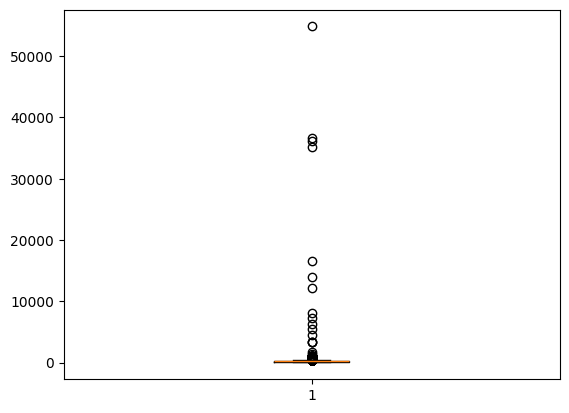

In [120]:
import matplotlib.pyplot as plt

plt.boxplot(df_encoded_sorted["tiempo_espera"])
plt.show()

In [121]:
## En esta aproximación eliminamos los outliers que están por encima de 1.5 veces el IQR
Q1 = df_encoded_sorted['tiempo_espera'].quantile(0.25)  # Primer cuartil
Q3 = df_encoded_sorted['tiempo_espera'].quantile(0.75)  # Tercer cuartil
IQR = Q3 - Q1  # Rango intercuartílico

# Definir límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar valores dentro de los límites
df_sin_outliers = df_encoded_sorted[(df_encoded_sorted['tiempo_espera'] >= limite_inferior) & (df_encoded_sorted['tiempo_espera'] <= limite_superior)]

print("DataFrame sin outliers:")
print(limite_inferior,limite_superior)
df_sin_outliers.head()

DataFrame sin outliers:
-13.77350000000007 429.6625000000001


,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,...,holding_point_LD,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,9504,344455,2025-01-31 22:08:29.804,2025-01-31 22:09:20.218,2025-01-31 22:10:51.249,141.445,Medium 2 (between 34000 kg to 136000 kg),-3.576268,40.492545,-3.575745,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,9503,06a2e9,2025-01-31 21:19:39.961,2025-01-31 21:22:18.826,2025-01-31 21:23:29.572,229.611,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560364,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9502,347588,2025-01-31 20:58:25.651,2025-01-31 20:59:09.268,2025-01-31 21:01:31.838,186.187,Medium 2 (between 34000 kg to 136000 kg),-3.576299,40.492521,-3.575760,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,9501,343141,2025-01-31 20:43:20.840,2025-01-31 20:44:26.935,2025-01-31 20:47:32.623,251.783,Medium 2 (between 34000 kg to 136000 kg),-3.576294,40.492516,-3.575769,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,9500,40768b,2025-01-31 19:52:24.254,2025-01-31 19:53:28.409,2025-01-31 19:55:52.739,208.485,Medium 2 (between 34000 kg to 136000 kg),-3.576111,40.491806,-3.575653,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


<Axes: >

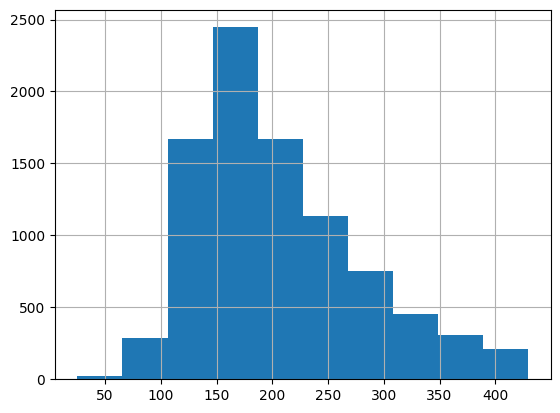

In [122]:
## Hemos conseguido mejorar la distribución de los tiempos de espera
df_sin_outliers["tiempo_espera"].hist()

In [123]:
df_sin_outliers = df_sin_outliers.sort_values(by = "despegue").reset_index(drop =True)
df_sin_outliers.head(5)

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,...,holding_point_LD,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,0,347518,2024-11-07 00:22:18.763,2024-11-07 00:26:21.023,2024-11-07 00:27:49.530,330.767,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560366,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,4cac23,2024-11-07 05:02:14.205,2024-11-07 05:05:59.154,2024-11-07 05:07:29.534,315.329,Medium 2 (between 34000 kg to 136000 kg),-3.576309,40.492504,-3.575760,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,484fde,2024-11-07 05:14:35.672,2024-11-07 05:15:28.070,2024-11-07 05:18:33.536,237.864,Medium 2 (between 34000 kg to 136000 kg),-3.576065,40.491829,-3.575623,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,3,344498,2024-11-07 05:39:07.268,2024-11-07 05:41:47.193,2024-11-07 05:43:01.991,234.723,Medium 2 (between 34000 kg to 136000 kg),-3.576294,40.492504,-3.575775,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,4cac54,2024-11-07 05:47:17.941,2024-11-07 05:47:44.246,2024-11-07 05:49:46.367,148.426,Medium 2 (between 34000 kg to 136000 kg),-3.575714,40.491943,-3.575623,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [124]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def resample_flight_data(df, interval_seconds=30):
    """
    Resample flight data to create rows at fixed intervals between arrival and departure times.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing flight data with columns 'ICAO', 'llegada_punto', 'salida_punto'
    interval_seconds : int
        Interval in seconds for resampling
        
    Returns:
    --------
    pandas.DataFrame
        Resampled DataFrame with additional rows and tiempo_esperando column
    """
    
    df['llegada_punto'] = pd.to_datetime(df['llegada_punto'])
    df['salida_punto'] = pd.to_datetime(df['salida_punto'])
    
    resampled_rows = []
    
    for _, flight in df.iterrows():
        arrival_time = flight['llegada_punto']
        departure_time = flight['salida_punto']
        tiempo_espera = flight["tiempo_espera"]
        
        time_diff = (departure_time - arrival_time).total_seconds()
        num_intervals = int(time_diff / interval_seconds) + 1
        
        for i in range(num_intervals):
            current_time = arrival_time + timedelta(seconds=i * interval_seconds)
            
            if current_time > departure_time:
                break
                
            new_row = flight.copy()
            
            tiempo_esperando = (current_time - arrival_time).total_seconds()
            
            new_row['tiempo_esperado'] = tiempo_esperando
            new_row["tiempo_espera"] = tiempo_espera -  tiempo_esperando
            new_row["llegada_punto"]+=  (current_time - arrival_time)
            
            resampled_rows.append(new_row)
    
    resampled_df = pd.DataFrame(resampled_rows)
    
    return resampled_df



In [125]:
## Usamos nuestro funcion para resamplear los datos,de esta forma tenemos una nueva columna con el tiempo que lleva esperando el avion en el punto de espera
df_sin_outliers = resample_flight_data(df_sin_outliers)


In [126]:
df_sin_outliers = df_sin_outliers.reset_index(drop = True)
df_sin_outliers

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,...,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,tiempo_esperado
0,0,347518,2024-11-07 00:22:18.763,2024-11-07 00:26:21.023,2024-11-07 00:27:49.530,330.767,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560366,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,347518,2024-11-07 00:22:48.763,2024-11-07 00:26:21.023,2024-11-07 00:27:49.530,300.767,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560366,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0
2,0,347518,2024-11-07 00:23:18.763,2024-11-07 00:26:21.023,2024-11-07 00:27:49.530,270.767,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560366,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0
3,0,347518,2024-11-07 00:23:48.763,2024-11-07 00:26:21.023,2024-11-07 00:27:49.530,240.767,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560366,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90.0
4,0,347518,2024-11-07 00:24:18.763,2024-11-07 00:26:21.023,2024-11-07 00:27:49.530,210.767,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560366,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33005,9503,06a2e9,2025-01-31 21:21:09.961,2025-01-31 21:22:18.826,2025-01-31 21:23:29.572,139.611,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560364,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90.0
33006,9503,06a2e9,2025-01-31 21:21:39.961,2025-01-31 21:22:18.826,2025-01-31 21:23:29.572,109.611,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560364,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0
33007,9503,06a2e9,2025-01-31 21:22:09.961,2025-01-31 21:22:18.826,2025-01-31 21:23:29.572,79.611,Heavy (larger than 136000 kg),-3.560928,40.499428,-3.560364,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0
33008,9504,344455,2025-01-31 22:08:29.804,2025-01-31 22:09:20.218,2025-01-31 22:10:51.249,141.445,Medium 2 (between 34000 kg to 136000 kg),-3.576268,40.492545,-3.575745,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [127]:
## Ahora vamos a obtener los holding points que estan ocupados en el momento de la llegada del avion
lista = []
for i, (index, row) in enumerate(df_sin_outliers.iterrows()):
    if (i -1)>=0:
        llegada_punto_referencia,salida_punto_referencia,despegue,holding_referencia,icao_referencia = row["llegada_punto"],row["salida_punto"],row["despegue"],row["holding_point"],row["ICAO"]
        filtered_df = df_sin_outliers[(df_sin_outliers["llegada_punto"] < llegada_punto_referencia) & (df_sin_outliers["salida_punto"] > llegada_punto_referencia)]
        filtered_df = filtered_df[filtered_df["ICAO"] != icao_referencia]
        lista.append(filtered_df[["index", "holding_point"]].values)

    

In [128]:
lista_filtrada = [
    [(idx, val) for idx, val in arr if val is not None]
    for arr in lista[1:] if any(val is not None for _, val in arr)
]


In [129]:
## Obtenemos para cada indice de avion, que otros holding points estan ocupados en el momento de la llegada del avion
lista_filtrada[:5] 

[[(9, 'Z4')], [(8, 'Y1'), (8, 'Y1')], [(11, 'Y1')], [(10, 'Z2')], [(35, 'K1')]]

In [130]:
from sklearn.cluster import DBSCAN
import numpy as np
## Solo nos interesan los holdin points que esten ocupados y cercanos al punto de espera del avion, por lo que vamos a crear cluster de holding points que esten cercanos
# Coordenadas extraídas del GeoJSON
coords = np.array([
    [-3.573093114831562, 40.490653160130186],  # Z1
    [-3.537524367869231, 40.472076292010001],  # KA6
    [-3.536653485337274, 40.466622566754253],  # KA8
    [-3.558959606954449, 40.494122669084419],  # K3
    [-3.559326044131887, 40.4945961819448],    # K2
    [-3.560411408421098, 40.495554592925956],  # K1
    [-3.560656492186808, 40.499431092287409],  # Y1
    [-3.560645785166937, 40.500298406173002],  # Y2
    [-3.560660061193443, 40.501183565039504],  # Y3
    [-3.560800449906033, 40.533391949745102],  # Y7
    [-3.576129307304151, 40.495184843931881],  # Z6
    [-3.576034129003182, 40.492555539298088],  # Z4
    [-3.575903257941006, 40.491865496230126],  # Z2
    [-3.57319305240692, 40.491819096186241],   # Z3
    [-3.572566658955927, 40.479721203031424],  # LF
    [-3.57652786733783, 40.483565816902733],   # L1
    [-3.577181028787666, 40.484251101106899],  # LA
    [-3.577553413710587, 40.484873329796898],  # LB
    [-3.575750378154376, 40.486690643924192],  # LC
    [-3.575150753600524, 40.486522892072891],  # LD
    [-3.574915186586964, 40.485580625293494]   # LE
])

# Convertir a metros
lat_mean = np.deg2rad(40.5)  # Latitud media en radianes
meters_per_lat = 111000
meters_per_lon = 84000  # 111000 * cos(40.5°)
coords_meters = coords * np.array([meters_per_lon, meters_per_lat])

# Aplicar DBSCAN
db = DBSCAN(eps=250, min_samples=1, metric='euclidean').fit(coords_meters)
labels = db.labels_

# Lista de puntos
points = ['Z1', 'KA6', 'KA8', 'K3', 'K2', 'K1', 'Y1', 'Y2', 'Y3', 'Y7', 'Z6', 'Z4', 'Z2', 'Z3', 'LF', 'L1', 'LA', 'LB', 'LC', 'LD', 'LE']

# Crear diccionario
mapping = {points[i]: f'Cluster_{labels[i]}' for i in range(len(points))}
print(mapping)

{'Z1': 'Cluster_0', 'KA6': 'Cluster_1', 'KA8': 'Cluster_2', 'K3': 'Cluster_3', 'K2': 'Cluster_3', 'K1': 'Cluster_3', 'Y1': 'Cluster_4', 'Y2': 'Cluster_4', 'Y3': 'Cluster_4', 'Y7': 'Cluster_5', 'Z6': 'Cluster_6', 'Z4': 'Cluster_0', 'Z2': 'Cluster_0', 'Z3': 'Cluster_0', 'LF': 'Cluster_7', 'L1': 'Cluster_8', 'LA': 'Cluster_8', 'LB': 'Cluster_8', 'LC': 'Cluster_8', 'LD': 'Cluster_8', 'LE': 'Cluster_8'}


In [131]:
mapping

{'Z1': 'Cluster_0',
 'KA6': 'Cluster_1',
 'KA8': 'Cluster_2',
 'K3': 'Cluster_3',
 'K2': 'Cluster_3',
 'K1': 'Cluster_3',
 'Y1': 'Cluster_4',
 'Y2': 'Cluster_4',
 'Y3': 'Cluster_4',
 'Y7': 'Cluster_5',
 'Z6': 'Cluster_6',
 'Z4': 'Cluster_0',
 'Z2': 'Cluster_0',
 'Z3': 'Cluster_0',
 'LF': 'Cluster_7',
 'L1': 'Cluster_8',
 'LA': 'Cluster_8',
 'LB': 'Cluster_8',
 'LC': 'Cluster_8',
 'LD': 'Cluster_8',
 'LE': 'Cluster_8'}

In [132]:
# Vamoa a crear una nueva columna que sea pistas ocupadas con la información del numero de pistas ocupadas adyacentes al punto de espera donde esta el avion
# Procesar lista_filtrada para contar holding points únicos por índice
from collections import defaultdict
holding_points_por_indice = defaultdict(set)
for sublista in lista_filtrada:
    indice = sublista[0][0]  # El índice es el mismo en toda la sublista
    for _, hp in sublista:
        holding_points_por_indice[indice].add(hp)



nuevo_dict = defaultdict(set)
for indice, holdings in holding_points_por_indice.items():
    nuevo_dict[indice] = {mapping[holding] for holding in holdings}

# Convertir a dict normal si lo prefieres
nuevo_dict = dict(nuevo_dict)

# Crear un diccionario con la cantidad de holding points únicos por índice
cantidad_hp_por_indice = {indice: len(hps) for indice, hps in nuevo_dict.items()}

# Añadir la columna 'pistas_ocupadas' al DataFrame
# Suponiendo que df_sin_outliers ya está definido (asegúrate de tenerlo cargado)
import pandas as pd
# Ejemplo: si no lo tienes cargado, descomenta y ajusta esto con tus datos reales
# df_sin_outliers = pd.read_csv('tu_archivo.csv')  

df_sin_outliers['pistas_ocupadas'] = df_sin_outliers['index'].map(cantidad_hp_por_indice).fillna(0).astype(int)

# Mostrar las primeras filas para verificar
print(df_sin_outliers[['index', 'ICAO', 'llegada_punto', 'salida_punto', 'pistas_ocupadas']].head())

   index    ICAO           llegada_punto            salida_punto  \
0      0  347518 2024-11-07 00:22:18.763 2024-11-07 00:26:21.023   
1      0  347518 2024-11-07 00:22:48.763 2024-11-07 00:26:21.023   
2      0  347518 2024-11-07 00:23:18.763 2024-11-07 00:26:21.023   
3      0  347518 2024-11-07 00:23:48.763 2024-11-07 00:26:21.023   
4      0  347518 2024-11-07 00:24:18.763 2024-11-07 00:26:21.023   

   pistas_ocupadas  
0                0  
1                0  
2                0  
3                0  
4                0  


In [133]:
df_sin_outliers["pistas_ocupadas"].value_counts()

pistas_ocupadas
0    21545
1    10793
2      672
Name: count, dtype: int64

In [134]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
X = df_sin_outliers.drop(columns=["tiempo_espera","index","ICAO","llegada_punto","salida_punto","despegue","fecha_despegue","holding_point","salida_lat","salida_lon","parado","hora_despegue","aircraft_type"])
y = df_sin_outliers["tiempo_espera"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test_indices = X_test.index

# Normalizar los datos de entrada
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Construcción del modelo
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)  # Capa de salida sin activación para regresión
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Configurar Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Entrenar el modelo con Early Stopping
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=128,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping]
)

# Evaluar el modelo
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Error absoluto medio en test: {test_mae:.2f}")


Epoch 1/200


/Users/hamzatriki/3ºProyectoDeDatos2/PD2/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 20009.8359 - mae: 114.9982 - val_loss: 4569.0405 - val_mae: 51.0269
Epoch 2/200
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6080.0137 - mae: 60.5431 - val_loss: 4322.8979 - val_mae: 50.7314
Epoch 3/200
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5678.0190 - mae: 58.3999 - val_loss: 4246.0283 - val_mae: 50.3478
Epoch 4/200
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5522.0200 - mae: 57.8137 - val_loss: 4149.5811 - val_mae: 50.3535
Epoch 5/200
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5474.0532 - mae: 57.3714 - val_loss: 4196.0767 - val_mae: 50.4198
Epoch 6/200
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5570.0225 - mae: 57.8265 - val_loss: 4271.8379 - val_mae: 50.0394
Epoch 7/200
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5455.4097 - mae: 57.3758 - val_loss: 4232.5122 - val_mae: 50.2046
Epoch 8/200
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5438.4429 - mae: 57.3827 - val_loss: 4198.7642 - val_mae: 49

In [135]:
X_train.columns

Index(['llegada_lon', 'llegada_lat',
       'aircraft_type_Heavy (larger than 136000 kg)',
       'aircraft_type_High vortex aircraft',
       'aircraft_type_Light (less than 7000 kg)',
       'aircraft_type_Medium 1 (between 7000 kg and 34000 kg)',
       'aircraft_type_Medium 2 (between 34000 kg to 136000 kg)',
       'holding_point_K1', 'holding_point_K2', 'holding_point_K3',
       'holding_point_KA6', 'holding_point_KA8', 'holding_point_LA',
       'holding_point_LB', 'holding_point_LC', 'holding_point_LD',
       'holding_point_LE', 'holding_point_Y1', 'holding_point_Y2',
       'holding_point_Y3', 'holding_point_Z1', 'holding_point_Z2',
       'holding_point_Z3', 'holding_point_Z4', 'holding_point_Z6',
       'tiempo_esperado', 'pistas_ocupadas'],
      dtype='object')

In [174]:
model.save("modelo_tiempo_espera_dense_sampled_con_pistas_ocupadas.keras")

In [87]:
y_pred = model.predict(X_test_scaled)

207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step


In [136]:
pd.concat([pd.DataFrame(df_sin_outliers.loc[X_test_indices].reset_index(drop = True)),pd.DataFrame(y_test.reset_index(drop = True)),pd.DataFrame(y_pred,columns = ["pred"])],axis =1).to_csv("/Users/hamzatriki/3ºProyectoDeDatos2/PD2/data/modelado/y_test_y_pred.csv")
pd.concat([pd.DataFrame(df_sin_outliers.loc[X_test_indices].reset_index(drop = True)),pd.DataFrame(y_test.reset_index(drop = True)),pd.DataFrame(y_pred,columns = ["pred"])],axis =1)

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,...,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,tiempo_esperado,pistas_ocupadas,tiempo_espera,pred
0,8074,347219,2025-01-18 19:02:38.824,2025-01-18 19:02:45.454,2025-01-18 19:04:18.744,99.920,Medium 2 (between 34000 kg to 136000 kg),-3.560944,40.499434,-3.560366,...,0.0,0.0,0.0,0.0,0.0,0.0,90.0,0,99.920,132.959747
1,841,347659,2024-11-12 23:11:36.187,2024-11-12 23:12:29.023,2024-11-12 23:14:50.941,194.754,Heavy (larger than 136000 kg),-3.560928,40.500298,-3.560366,...,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0,194.754,175.155869
2,3559,3ca083,2024-12-10 15:08:06.714,2024-12-10 15:08:41.331,2024-12-10 15:10:43.144,156.430,Medium 1 (between 7000 kg and 34000 kg),-3.560944,40.499416,-3.560349,...,0.0,0.0,0.0,0.0,0.0,0.0,30.0,1,156.430,210.702209
3,8974,34134d,2025-01-26 21:06:10.855,2025-01-26 21:07:03.619,2025-01-26 21:08:26.295,135.440,Medium 2 (between 34000 kg to 136000 kg),-3.559539,40.494488,-3.559097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,135.440,175.148376
4,1132,3420ca,2024-11-15 12:39:46.188,2024-11-15 12:39:59.039,2024-11-15 12:41:36.185,109.997,Medium 2 (between 34000 kg to 136000 kg),-3.559555,40.494484,-3.559052,...,0.0,0.0,0.0,0.0,0.0,0.0,90.0,0,109.997,145.242386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6597,6460,4cac24,2025-01-04 04:56:35.419,2025-01-04 04:59:21.929,2025-01-04 05:00:42.912,247.493,Medium 2 (between 34000 kg to 136000 kg),-3.576126,40.491726,-3.575638,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,247.493,214.977982
6598,5215,345251,2024-12-23 15:57:02.487,2024-12-23 15:57:12.680,2024-12-23 16:00:06.385,183.898,Heavy (larger than 136000 kg),-3.576159,40.491777,-3.575628,...,0.0,0.0,1.0,0.0,0.0,0.0,60.0,0,183.898,175.740479
6599,578,4d244b,2024-11-10 20:00:14.096,2024-11-10 20:00:28.855,2024-11-10 20:01:27.189,73.093,Medium 2 (between 34000 kg to 136000 kg),-3.559523,40.494488,-3.559071,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,73.093,175.141495
6600,4517,4d2384,2024-12-18 12:07:24.925,2024-12-18 12:07:38.743,2024-12-18 12:09:17.313,112.388,Medium 2 (between 34000 kg to 136000 kg),-3.576143,40.491742,-3.575628,...,0.0,0.0,1.0,0.0,0.0,0.0,30.0,0,112.388,187.520874


In [137]:
# Evaluar el modelo
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Error absoluto medio en test: {test_mae:.2f}")

207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 4080.7966 - mae: 49.9325
Error absoluto medio en test: 49.62


In [138]:
# Crear gráfico interactivo con Plotly

results_df = pd.DataFrame({
    'holding_point': df_sin_outliers.loc[X_test_indices, 'holding_point'],
    'real': y_test.values,
    'predicho': y_pred.flatten(),
    'ICAO': df_sin_outliers.loc[X_test_indices, 'ICAO'],
    'llegada_punto': df_sin_outliers.loc[X_test_indices, 'llegada_punto'],
    'salida_punto': df_sin_outliers.loc[X_test_indices, 'salida_punto'],
    'despegue': df_sin_outliers.loc[X_test_indices, 'despegue'],
    'fecha_despegue': df_sin_outliers.loc[X_test_indices, 'fecha_despegue'],
    'pistas_ocupadas':df_sin_outliers.loc[X_test_indices, 'pistas_ocupadas'],
    'parado':df_sin_outliers.loc[X_test_indices,"parado"]
})
from plotly import graph_objects as go
import plotly.express as px
fig = go.Figure()

# Añadir trazas para cada holding_point
for point in results_df['holding_point'].unique():
    subset = results_df[results_df['holding_point'] == point]
    fig.add_trace(
        go.Scatter(
            x=subset['real'],
            y=subset['predicho'],
            mode='markers',
            name=point,
            text=[f"ICAO: {row['ICAO']}<br>"
                  f"Holding Point: {row['holding_point']}<br>"
                  f"Real: {row['real']:.2f}<br>"
                  f"Predicho: {row['predicho']:.2f}<br>"
                  f"Llegada: {row['llegada_punto']}<br>"
                  f"Salida: {row['salida_punto']}<br>"
                  f": {row['salida_punto']}<br>"
                  f"Despegue: {row['despegue']}<br>"
                  f"pistas_ocupadas: {row['pistas_ocupadas']}<br>"
                  f"Parado: {row['parado']}<br>"
                  f"Fecha: {row['fecha_despegue']}"
                  for _, row in subset.iterrows()],
            hoverinfo='text',
            visible=True
        )
    )

# Añadir línea de referencia y=x
min_val = min(results_df['real'].min(), results_df['predicho'].min())
max_val = max(results_df['real'].max(), results_df['predicho'].max())
fig.add_trace(
    go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode='lines',
        line=dict(color='red', dash='dash'),
        name='y=x',
        visible=True
    )
)

# Crear botones para el filtro
buttons = [
    dict(
        label='Todos',
        method='update',
        args=[{'visible': [True] * len(results_df['holding_point'].unique()) + [True]},  # +1 para la línea y=x
              {'title': 'Predicciones vs Valores Reales (Todos los Holding Points)'}]
    )
]

for i, point in enumerate(results_df['holding_point'].unique()):
    visible = [False] * len(results_df['holding_point'].unique())
    visible[i] = True
    buttons.append(
        dict(
            label=point,
            method='update',
            args=[{'visible': visible + [True]},  # +[True] para mantener la línea y=x visible
                  {'title': f'Predicciones vs Valores Reales (Holding Point: {point})'}]
        )
    )

# Actualizar el layout con el dropdown
fig.update_layout(
    title='Predicciones vs Valores Reales por Holding Point',
    xaxis_title='Tiempo de espera real',
    yaxis_title='Tiempo de espera predicho',
    updatemenus=[
        dict(
            buttons=buttons,
            direction='down',
            showactive=True,
            x=0.1,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )
    ],
    showlegend=True,
    hovermode='closest'
)

# Mostrar el gráfico
fig.show()

# Opcional: Gráfico de barras de error por holding_point
error_by_point = results_df.groupby('holding_point').apply(
    lambda x: np.mean(np.abs(x['real'] - x['predicho']))
)

fig_bar = px.bar(
    x=error_by_point.index,
    y=error_by_point.values,
    labels={'x': 'Holding Point', 'y': 'MAE'},
    title='Error Absoluto Medio por Holding Point'
)
fig_bar.update_layout(xaxis={'tickangle': 45})
fig_bar.show()

/var/folders/kf/v4wgzcdn2k5_yn3_h219svlm0000gn/T/ipykernel_41450/3878209168.py:105: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

